In [5]:
import os
import argparse
import time
from warnings import simplefilter
import gymnasium as gym
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

from RARL.DDQNSingle import DDQNSingle
from RARL.Trainer import Trainer
from RARL.config import dqnConfig, ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import plot_protagonist_adversary_actions, plot_RA_eval, plot_protagonist_adversary_values, PlotConfig
from gym_reachability import gym_reachability  # Custom Gym env.

# matplotlib.use('Agg')

simplefilter(action='ignore', category=FutureWarning)
timestr = time.strftime("%Y-%m-%d-%H_%M")

# == ARGS ==
parser = argparse.ArgumentParser()

# environment parameters
parser.add_argument(
    "-dt", "--doneType", help="when to raise done flag", default='TF',
    type=str
)
parser.add_argument(
    "-ct", "--costType", help="cost type", default='max', type=str
)
parser.add_argument(
    "-rnd", "--randomSeed", help="random seed", default=0, type=int
)
parser.add_argument(
    "-r", "--reward", help="when entering target set", default=-1, type=float
)
parser.add_argument(
    "-p", "--penalty", help="when entering failure set", default=1, type=float
)
parser.add_argument(
    "-s", "--scaling", help="scaling of ell/g", default=4, type=float
)

# training scheme
parser.add_argument(
    "-w", "--warmup", help="warmup Q-network", action="store_true"
)
parser.add_argument(
    "-wi", "--warmupIter", help="warmup iteration", default=2000, type=int
)
parser.add_argument(
    "-mu", "--maxUpdates", help="maximal #gradient updates", default=300000,
    type=int
)
parser.add_argument(
    "-ut", "--updateTimes", help="#hyper-param. steps", default=10, type=int
)
parser.add_argument(
    "-mc", "--memoryCapacity", help="memoryCapacity", default=10000, type=int
)
parser.add_argument(
    "-cp", "--checkPeriod", help="check period", default=20000, type=int
)

# NN hyper-parameters
parser.add_argument(
    "-a", "--annealing", help="gamma annealing", action="store_true"
)
parser.add_argument(
    "-arc", "--architecture", help="NN architecture", default=[100, 20],
    nargs="*", type=int
)
parser.add_argument(
    "-lr", "--learningRate", help="learning rate", default=1e-3, type=float
)
parser.add_argument(
    "-g", "--gamma", help="contraction coeff.", default=0.9999, type=float
)
parser.add_argument(
    "-act", "--actType", help="activation type", default='Tanh', type=str
)
parser.add_argument(
    "-nc", "--numCritics", help="number of critics", default=3, type=int
)

# RL type
parser.add_argument("-m", "--mode", help="mode", default='AARA', type=str)
parser.add_argument(
    "-tt", "--terminalType", help="terminal value", default='max', type=str
)

# file
parser.add_argument(
    "-st", "--showTime", help="show timestr", action="store_true"
)
parser.add_argument("-n", "--name", help="extra name", default='', type=str)
parser.add_argument(
    "-of", "--outFolder", help="output file", default='experiments', type=str
)
parser.add_argument(
    "-pf", "--plotFigure", help="plot figures", action="store_true"
)
parser.add_argument(
    "-sf", "--storeFigure", help="store figures", action="store_true"
)

args, unknown = parser.parse_known_args()
print(args)
print()

# == CONFIGURATION ==
env_name = "zermelo_show-v0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
maxUpdates = args.maxUpdates
updateTimes = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
maxSteps = 250
storeFigure = args.storeFigure
plotFigure = args.plotFigure

fn = args.name + 'TF'
if args.showTime:
  fn = fn + '-' + timestr

outFolder = 'experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59'
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')


if args.mode == 'RA':
  agentMode = 'RA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

elif args.mode == 'AARA':
  agentMode = 'AARA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

sample_inside_obs = False

# == Environment ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, device=device,
    sample_inside_obs=sample_inside_obs, envType="basic"
)

stateDim = env.unwrapped.state.shape[0]
actionNum = env.unwrapped.action_space.n
action_list = np.arange(actionNum)
print(
    "State Dimension: {:d}, ActionSpace Dimension: {:d}".format(
        stateDim, actionNum
    )
)
print(f"Discrete Controls: {env.unwrapped.discrete_controls}")

env.unwrapped.set_costParam(args.penalty, args.reward, args.costType, args.scaling) # only needed for Lagrange
env.unwrapped.set_seed(args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")
PRO_CONFIG = dqnConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100
)

args.architecture = [120,20]
ADV_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100, NUM_CRITICS=args.numCritics
)

# == TRAINER ==
trainer = Trainer(PRO_CONFIG)

# == PROTAGONIST AGENT ==
dimList = [stateDim] + PRO_CONFIG.ARCHITECTURE + [actionNum]
protagonist = DDQNSingle(
    PRO_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, protagonist.device))
print("Critic is using cuda: ", next(protagonist.Q_network.parameters()).is_cuda)


# == ADVERSARY AGENT ==
dimList = [stateDim + 1] + ADV_CONFIG.ARCHITECTURE + [actionNum] # +1 for sending the action into the adversary network 
adversary = DDQNSingle(
    ADV_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, adversary.device))
print("Critic is using cuda: ", next(adversary.Q_network.parameters()).is_cuda)

vmin = -1 * args.scaling
vmax = 1 * args.scaling
checkPeriod = args.checkPeriod

Namespace(doneType='TF', costType='max', randomSeed=0, reward=-1, penalty=1, scaling=4, warmup=False, warmupIter=2000, maxUpdates=300000, updateTimes=10, memoryCapacity=10000, checkPeriod=20000, annealing=False, architecture=[100, 20], learningRate=0.001, gamma=0.9999, actType='Tanh', numCritic=3, mode='AARA', terminalType='max', showTime=False, name='', outFolder='experiments', plotFigure=False, storeFigure=False)

experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59

== Environment Information ==
Env: mode-AARA; doneType-toEnd; sample_inside_obs-False
State Dimension: 2, ActionSpace Dimension: 3
Discrete Controls: [[-1.   1.5]
 [ 0.   1.5]
 [ 1.   1.5]]

== Agent Information ==
ModuleList(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=3, bias=True)
  (5): Identity()
)
DDQN: mode-AARA; terminalType-max
We want to use: cuda, and Agent uses: cud

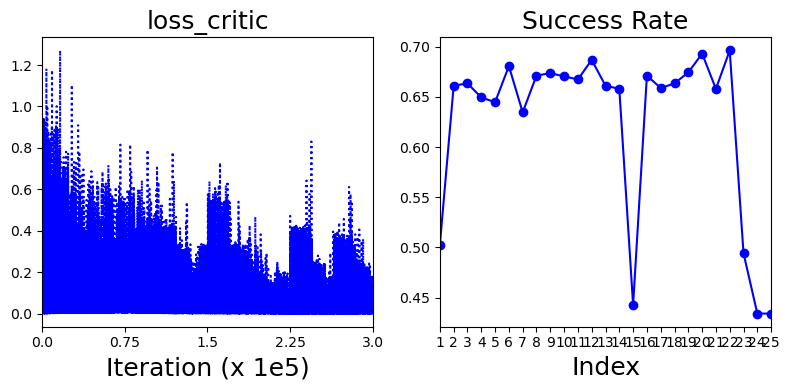

We pick model with success rate-0.696
  => Restore experiments/point-mass/SAC/AARA/TF-2026-03-28-23_14_59/pro_model/Q-440000.pth
Analytical Success Rate for Maximal Disturbances-0.598
Analytical Success Rate for No Disturbances-0.727
Best RA Success Rate with Adversarial Disturbances-0.425


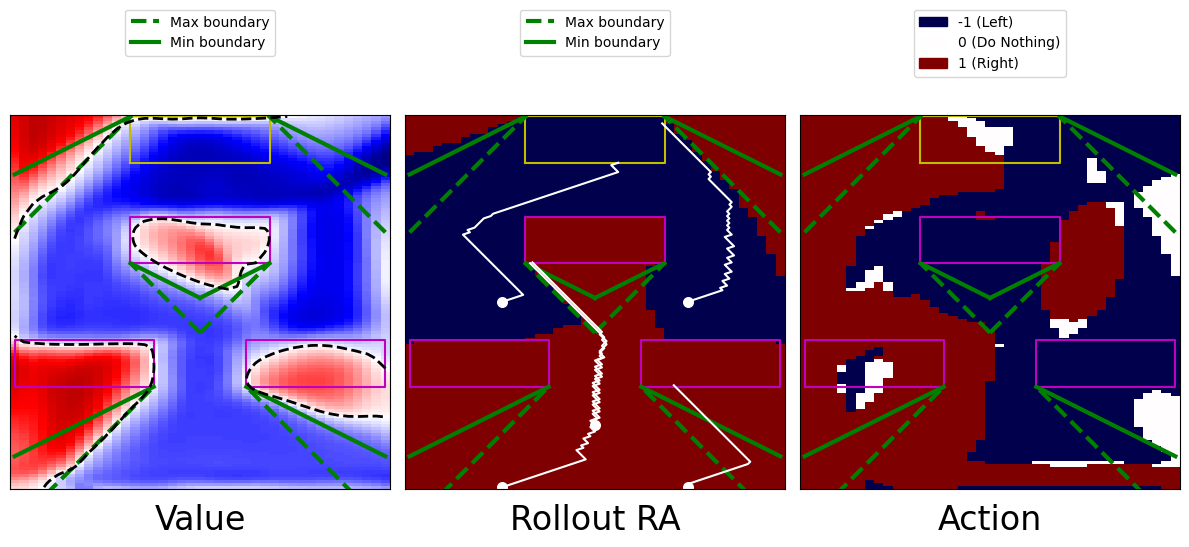

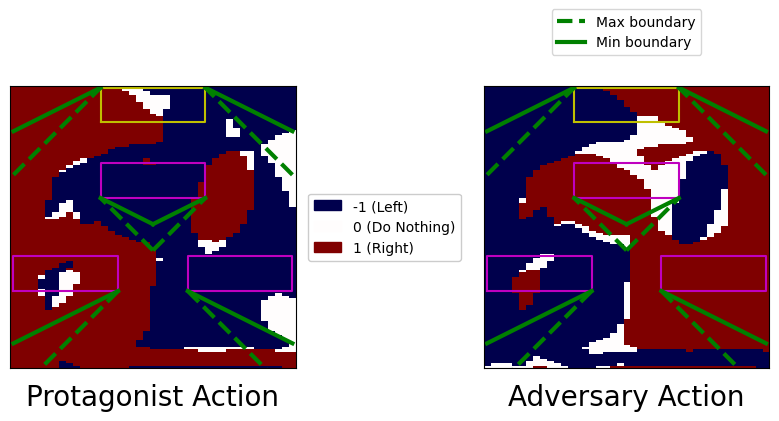

In [7]:
filePath = os.path.join(outFolder, 'train')
trainDict = load_obj(filePath)
trainRecords = trainDict['trainRecords']
trainProgress = trainDict['trainProgress']
resultMtx = trainDict['resultMtx']
actDistMtx = trainDict['actDistMtx']
disturbDistMtx = trainDict['disturbDistMtx']

plotFigure = True

if plotFigure or storeFigure:
  # = loss
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  data = trainRecords
  ax = axes[0]
  ax.plot(data, 'b:')
  ax.set_xlabel('Iteration (x 1e5)', fontsize=18)
  ax.set_xticks(np.linspace(0, maxUpdates, 5))
  ax.set_xticklabels(np.linspace(0, maxUpdates, 5) / 1e5)
  ax.set_title('loss_critic', fontsize=18)
  ax.set_xlim(left=0, right=maxUpdates)

  data = trainProgress[:, 0]
  ax = axes[1]
  x = np.arange(data.shape[0]) + 1
  ax.plot(x, data, 'b-o')
  ax.set_xlabel('Index', fontsize=18)
  ax.set_xticks(x)
  # ax.set_xticklabels(np.arange(data.shape[0]) + 1)
  ax.set_title('Success Rate', fontsize=18)
  ax.set_xlim(left=1, right=data.shape[0])

  fig.tight_layout()
  if storeFigure:
    figurePath = os.path.join(figureFolder, 'train_loss_success.png')
    fig.savefig(figurePath)
  if plotFigure:
    plt.show()
    plt.pause(0.001)
  plt.close()

  # = value_rollout_action
  idx = np.argmax(trainProgress[:, 0]) + 1
  successRate = np.amax(trainProgress[:, 0])
  print('We pick model with success rate-{:.3f}'.format(successRate))
  protagonist.restore(idx * args.checkPeriod, outFolder, prefix="pro_")
  # adversary.restore(idx * args.checkPeriod, outFolder, prefix="adv_")

  nx = 41
  ny = 121
  xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
  ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)

  resultMtx = np.empty((nx, ny), dtype=int)
  actDistMtx = np.empty((nx, ny), dtype=int)
  disturbDistMtx = np.empty((nx, ny), dtype=int)
  it = np.nditer(resultMtx, flags=['multi_index'])
  analytic_max_fail = 0
  analytic_min_fail = 0

  while not it.finished:
    idx = it.multi_index
    print(idx, end='\r')
    x = xs[idx[0]]
    y = ys[idx[1]]

    state = np.array([x, y])
    stateTensor = torch.FloatTensor(state).to(device).unsqueeze(0)
    action_index = protagonist.Q_network(stateTensor).min(dim=1)[1].cpu().item()
    # u = env.discrete_controls[action_index]
    # sa = torch.cat([stateTensor, torch.tensor([[action_index]], dtype=torch.float32).to(device)], dim=1)
    disturb_index = protagonist.Q_network(stateTensor).max(dim=1)[1].cpu().item()
    actDistMtx[idx] = action_index
    disturbDistMtx[idx] = disturb_index

    _, _, result = env.unwrapped.simulate_one_trajectory(
        protagonist.Q_network, adversary.Q_network, T=250, state=state
    )
    
    g_x = env.unwrapped.safety_margin(state)
    inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x > 0:
      analytic_min_fail += 1
      analytic_max_fail += 1
    else:
      if inside_max_diag:
        analytic_max_fail += 1
      if inside_min_diag: 
        analytic_min_fail += 1

    resultMtx[idx] = result
    it.iternext()

  print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(1 - analytic_max_fail/(nx*ny)))
  print('Analytical Success Rate for No Disturbances-{:.3f}'.format(1 - analytic_min_fail/(nx*ny)))
  print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format((resultMtx == 1).sum()/(nx*ny)))

  cfg = PlotConfig(nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax, resultMtx=resultMtx, 
                   actDistMtx=actDistMtx, disturbDistMtx=disturbDistMtx, figureFolder=figureFolder, 
                   plotFigure=True, storeFigure=True, actionNum=actionNum)

  plot_RA_eval(env, protagonist, adversary, cfg)

  plot_protagonist_adversary_actions(env, protagonist, adversary, cfg)

  # plot_protagonist_adversary_values(env, protagonist, adversary, cfg)
  

**Test against adversarial**

Namespace(doneType='TF', costType='max', randomSeed=0, reward=-1, penalty=1, scaling=4, warmup=False, warmupIter=2000, maxUpdates=300000, updateTimes=10, memoryCapacity=10000, checkPeriod=20000, annealing=False, architecture=[100, 20], learningRate=0.001, gamma=0.9999, actType='Tanh', numCritic=3, mode='AARA', terminalType='max', showTime=False, name='', outFolder='experiments', plotFigure=False, storeFigure=False)

experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46

== Environment Information ==
Env: mode-AARA; doneType-toEnd; sample_inside_obs-False
State Dimension: 2, ActionSpace Dimension: 3
Discrete Controls: [[-1.   1.5]
 [ 0.   1.5]
 [ 1.   1.5]]

== Agent Information ==
ModuleList(
  (0): Linear(in_features=2, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=3, bias=True)
  (5): Identity()
)
DDQN: mode-AARA; terminalType-max
We want to use: cuda, and Agent uses: cud

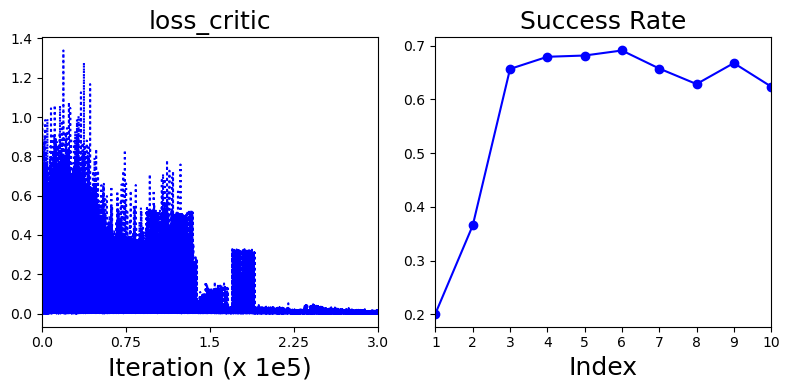

We pick model with success rate-0.691
  => Restore experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46/pro_model/Q-120000.pth
Analytical Success Rate for Maximal Disturbances-0.614
Analytical Success Rate for No Disturbances-0.727
Best RA Success Rate with Adversarial Disturbances-0.613


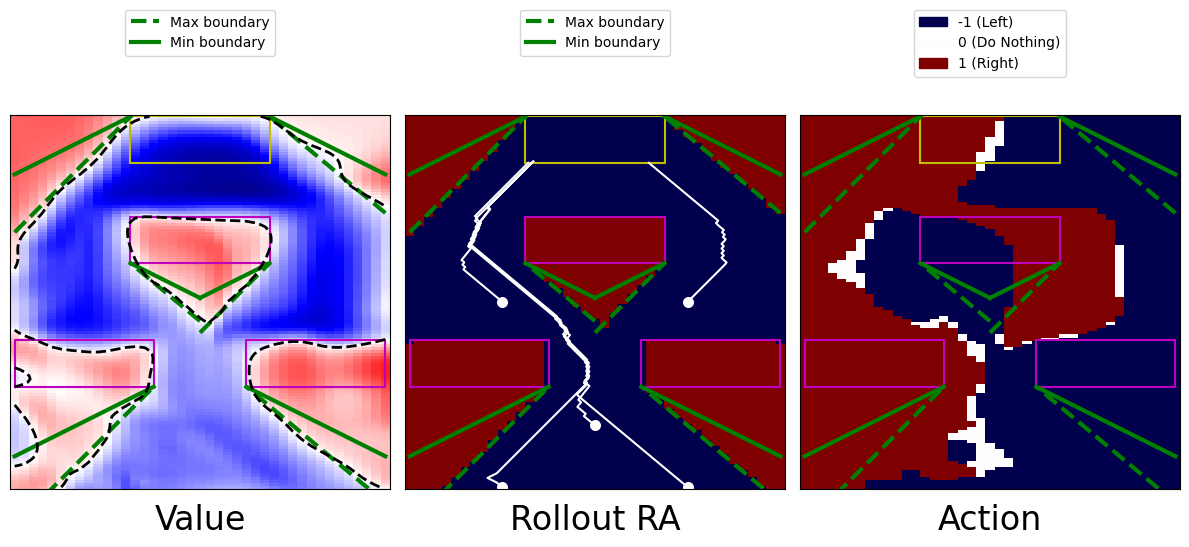

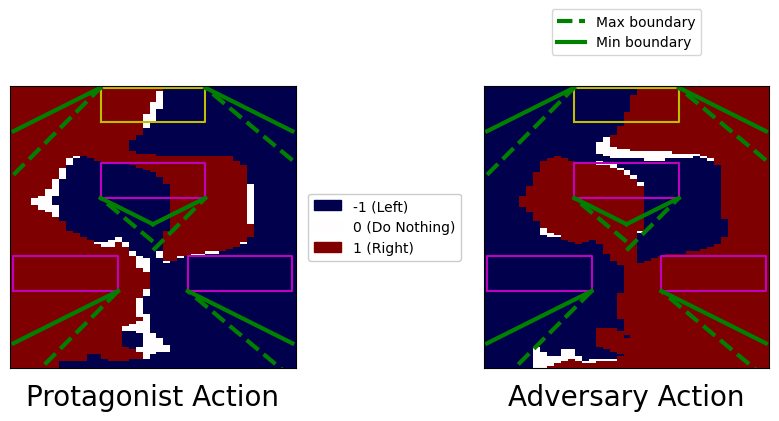

In [2]:
import os
import argparse
import time
from warnings import simplefilter
import gymnasium as gym
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

from RARL.DDQNSingle import DDQNSingle
from RARL.Trainer import Trainer
from RARL.config import dqnConfig, ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import plot_protagonist_adversary_actions, plot_RA_eval, plot_protagonist_adversary_values, PlotConfig
from gym_reachability import gym_reachability  # Custom Gym env.

# matplotlib.use('Agg')

simplefilter(action='ignore', category=FutureWarning)
timestr = time.strftime("%Y-%m-%d-%H_%M")

# == ARGS ==
parser = argparse.ArgumentParser()

# environment parameters
parser.add_argument(
    "-dt", "--doneType", help="when to raise done flag", default='TF',
    type=str
)
parser.add_argument(
    "-ct", "--costType", help="cost type", default='max', type=str
)
parser.add_argument(
    "-rnd", "--randomSeed", help="random seed", default=0, type=int
)
parser.add_argument(
    "-r", "--reward", help="when entering target set", default=-1, type=float
)
parser.add_argument(
    "-p", "--penalty", help="when entering failure set", default=1, type=float
)
parser.add_argument(
    "-s", "--scaling", help="scaling of ell/g", default=4, type=float
)

# training scheme
parser.add_argument(
    "-w", "--warmup", help="warmup Q-network", action="store_true"
)
parser.add_argument(
    "-wi", "--warmupIter", help="warmup iteration", default=2000, type=int
)
parser.add_argument(
    "-mu", "--maxUpdates", help="maximal #gradient updates", default=300000,
    type=int
)
parser.add_argument(
    "-ut", "--updateTimes", help="#hyper-param. steps", default=10, type=int
)
parser.add_argument(
    "-mc", "--memoryCapacity", help="memoryCapacity", default=10000, type=int
)
parser.add_argument(
    "-cp", "--checkPeriod", help="check period", default=20000, type=int
)

# NN hyper-parameters
parser.add_argument(
    "-a", "--annealing", help="gamma annealing", action="store_true"
)
parser.add_argument(
    "-arc", "--architecture", help="NN architecture", default=[100, 20],
    nargs="*", type=int
)
parser.add_argument(
    "-lr", "--learningRate", help="learning rate", default=1e-3, type=float
)
parser.add_argument(
    "-g", "--gamma", help="contraction coeff.", default=0.9999, type=float
)
parser.add_argument(
    "-act", "--actType", help="activation type", default='Tanh', type=str
)
parser.add_argument(
    "-nc", "--numCritics", help="number of critics", default=3, type=int
)

# RL type
parser.add_argument("-m", "--mode", help="mode", default='AARA', type=str)
parser.add_argument(
    "-tt", "--terminalType", help="terminal value", default='max', type=str
)

# file
parser.add_argument(
    "-st", "--showTime", help="show timestr", action="store_true"
)
parser.add_argument("-n", "--name", help="extra name", default='', type=str)
parser.add_argument(
    "-of", "--outFolder", help="output file", default='experiments', type=str
)
parser.add_argument(
    "-pf", "--plotFigure", help="plot figures", action="store_true"
)
parser.add_argument(
    "-sf", "--storeFigure", help="store figures", action="store_true"
)

args, unknown = parser.parse_known_args()
print(args)
print()

# == CONFIGURATION ==
env_name = "zermelo_show-v0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
maxUpdates = args.maxUpdates
updateTimes = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
maxSteps = 250
storeFigure = args.storeFigure
plotFigure = args.plotFigure

fn = args.name + 'TF'
if args.showTime:
  fn = fn + '-' + timestr

outFolder = 'experiments/point-mass/SAC/AARA/TF-2026-03-30-09_19_46'
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')


if args.mode == 'RA':
  agentMode = 'RA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

elif args.mode == 'AARA':
  agentMode = 'AARA'
  if args.annealing:
    GAMMA_END = 0.999999
    EPS_PERIOD = int(updatePeriod / 10)
    EPS_RESET_PERIOD = updatePeriod
  else:
    GAMMA_END = args.gamma
    EPS_PERIOD = updatePeriod
    EPS_RESET_PERIOD = maxUpdates

sample_inside_obs = False

# == Environment ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, device=device,
    sample_inside_obs=sample_inside_obs, envType="basic"
)

stateDim = env.unwrapped.state.shape[0]
actionNum = env.unwrapped.action_space.n
action_list = np.arange(actionNum)
print(
    "State Dimension: {:d}, ActionSpace Dimension: {:d}".format(
        stateDim, actionNum
    )
)
print(f"Discrete Controls: {env.unwrapped.discrete_controls}")

env.unwrapped.set_costParam(args.penalty, args.reward, args.costType, args.scaling) # only needed for Lagrange
env.unwrapped.set_seed(args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")
PRO_CONFIG = dqnConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100
)

args.architecture = [120,20]
ADV_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100, NUM_CRITICS=args.numCritics
)

# == TRAINER ==
trainer = Trainer(PRO_CONFIG)

# == PROTAGONIST AGENT ==
dimList = [stateDim] + PRO_CONFIG.ARCHITECTURE + [actionNum]
protagonist = DDQNSingle(
    PRO_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, protagonist.device))
print("Critic is using cuda: ", next(protagonist.Q_network.parameters()).is_cuda)


# == ADVERSARY AGENT ==
dimList = [stateDim + 1] + ADV_CONFIG.ARCHITECTURE + [actionNum] # +1 for sending the action into the adversary network 
adversary = DDQNSingle(
    ADV_CONFIG, actionNum, trainer.memory, dimList=dimList, mode=agentMode,
    terminalType=args.terminalType
)
print("We want to use: {}, and Agent uses: {}".format(device, adversary.device))
print("Critic is using cuda: ", next(adversary.Q_network.parameters()).is_cuda)

vmin = -1 * args.scaling
vmax = 1 * args.scaling
checkPeriod = args.checkPeriod



filePath = os.path.join(outFolder, 'train')
trainDict = load_obj(filePath)
trainRecords = trainDict['trainRecords']
trainProgress = trainDict['trainProgress']
resultMtx = trainDict['resultMtx']
actDistMtx = trainDict['actDistMtx']
disturbDistMtx = trainDict['disturbDistMtx']

plotFigure = True

if plotFigure or storeFigure:
  # = loss
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  data = trainRecords
  ax = axes[0]
  ax.plot(data, 'b:')
  ax.set_xlabel('Iteration (x 1e5)', fontsize=18)
  ax.set_xticks(np.linspace(0, maxUpdates, 5))
  ax.set_xticklabels(np.linspace(0, maxUpdates, 5) / 1e5)
  ax.set_title('loss_critic', fontsize=18)
  ax.set_xlim(left=0, right=maxUpdates)

  data = trainProgress[:, 0]
  ax = axes[1]
  x = np.arange(data.shape[0]) + 1
  ax.plot(x, data, 'b-o')
  ax.set_xlabel('Index', fontsize=18)
  ax.set_xticks(x)
  # ax.set_xticklabels(np.arange(data.shape[0]) + 1)
  ax.set_title('Success Rate', fontsize=18)
  ax.set_xlim(left=1, right=data.shape[0])

  fig.tight_layout()
  if storeFigure:
    figurePath = os.path.join(figureFolder, 'train_loss_success.png')
    fig.savefig(figurePath)
  if plotFigure:
    plt.show()
    plt.pause(0.001)
  plt.close()

  # = value_rollout_action
  idx = np.argmax(trainProgress[:, 0]) + 1
  successRate = np.amax(trainProgress[:, 0])
  print('We pick model with success rate-{:.3f}'.format(successRate))
  protagonist.restore(idx * args.checkPeriod, outFolder, prefix="pro_")
  # adversary.restore(idx * args.checkPeriod, outFolder, prefix="adv_")

  nx = 41
  ny = 121
  xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
  ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)

  resultMtx = np.empty((nx, ny), dtype=int)
  actDistMtx = np.empty((nx, ny), dtype=int)
  disturbDistMtx = np.empty((nx, ny), dtype=int)
  it = np.nditer(resultMtx, flags=['multi_index'])
  analytic_max_fail = 0
  analytic_min_fail = 0

  while not it.finished:
    idx = it.multi_index
    print(idx, end='\r')
    x = xs[idx[0]]
    y = ys[idx[1]]

    state = np.array([x, y])
    stateTensor = torch.FloatTensor(state).to(device).unsqueeze(0)
    action_index = protagonist.Q_network(stateTensor).min(dim=1)[1].cpu().item()
    # u = env.discrete_controls[action_index]
    # sa = torch.cat([stateTensor, torch.tensor([[action_index]], dtype=torch.float32).to(device)], dim=1)
    disturb_index = protagonist.Q_network(stateTensor).max(dim=1)[1].cpu().item()
    # disturb_index = protagonist.select_action(state, env, agent='adv', explore=False)
    actDistMtx[idx] = action_index
    disturbDistMtx[idx] = disturb_index

    _, _, result = env.unwrapped.simulate_one_trajectory(
        protagonist.Q_network, adversary.Q_network, T=250, state=state
    )
    
    g_x = env.unwrapped.safety_margin(state)
    inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x > 0:
      analytic_min_fail += 1
      analytic_max_fail += 1
    else:
      if inside_max_diag:
        analytic_max_fail += 1
      if inside_min_diag: 
        analytic_min_fail += 1

    resultMtx[idx] = result
    it.iternext()

  print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(1 - analytic_max_fail/(nx*ny)))
  print('Analytical Success Rate for No Disturbances-{:.3f}'.format(1 - analytic_min_fail/(nx*ny)))
  print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format((resultMtx == 1).sum()/(nx*ny)))

  cfg = PlotConfig(nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax, resultMtx=resultMtx, 
                   actDistMtx=actDistMtx, disturbDistMtx=disturbDistMtx, figureFolder=figureFolder, 
                   plotFigure=True, storeFigure=True, actionNum=actionNum)

  plot_RA_eval(env, protagonist, adversary, cfg)

  plot_protagonist_adversary_actions(env, protagonist, adversary, cfg)  

# ***Test Sim Ensemble*** #

In [ ]:
"""
Please contact the author(s) of this library if you have any questions.
Authors: George Nehma ( gnehma2020@fit.edu )

Ensemble variant of sim_new_point_mass.py. Protagonist is a DDQNEnsemble
(N critics, seed-diversified) instead of DDQNSingle. Everything else —
Trainer, adversary, env, config loading — is identical to sim_new_point_mass.py.

After the standard training / eval block an extra section computes and saves
the epistemic uncertainty maps (variance of Q across critics, conservative
min-Q value, and safe/unsafe classification disagreement).

Examples:
    python3 sim_ensemble.py --config config.yaml
    python3 sim_ensemble.py --config config_5critics.yaml
"""

import os
import time
from warnings import simplefilter

import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml
from types import SimpleNamespace

# CHANGED: DDQNEnsemble as protagonist
from RARL.DDQNEnsemble import DDQNEnsemble
from RARL.DDQNSingle import DDQNSingle          # adversary unchanged
from RARL.Trainer import Trainer
from RARL.config import ceConfig, dqnConfig
from RARL.utils import save_obj
from utils.utils import (
    plot_protagonist_adversary_actions,
    plot_RA_eval,
    PlotConfig,
)
from gym_reachability import gym_reachability    # noqa: F401 — registers envs

import argparse

matplotlib.use('Agg')
simplefilter(action='ignore', category=FutureWarning)
timestr = time.strftime("%Y-%m-%d-%H_%M_%S")

# == ARGS — YAML config, same as sim_new_point_mass.py ==

with open("/home/exx/ra_rl/experiments/ensemble/3critics/point-mass/SAC/AARA/TF-2026-04-27-16_00_45/pro_model/critic_0/CONFIG.yaml", "r") as f:
    config = yaml.safe_load(f)

args = SimpleNamespace(**{k: v for section in config.values() for k, v in section.items()})
print(args)

# == CONFIGURATION ==
env_name     = "zermelo_show-v0"
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
maxUpdates   = args.maxUpdates
updateTimes  = args.updateTimes
updatePeriod = int(maxUpdates / updateTimes)
maxSteps     = 250                              # matches updated sim_new_point_mass.py
storeFigure  = args.storeFigure
plotFigure   = args.plotFigure

fn = args.name + 'TF'
if args.showTime:
    fn = fn + '-' + timestr

outFolder    = "/home/exx/ra_rl/experiments/ensemble/3critics/point-mass/SAC/AARA/TF-2026-04-27-16_00_45"
figureFolder = os.path.join(outFolder, 'figure')
print(outFolder)

# == Epsilon / gamma schedule — identical to sim_new_point_mass.py ==
if args.mode == 'RA':
    agentMode = 'RA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(updatePeriod / 10)
        EPS_RESET_PERIOD = updatePeriod
    else:
        GAMMA_END        = args.gamma
        EPS_PERIOD       = updatePeriod
        EPS_RESET_PERIOD = maxUpdates

elif args.mode == 'AARA':
    agentMode = 'AARA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(updatePeriod / 10)
        EPS_RESET_PERIOD = updatePeriod
    else:
        GAMMA_END        = args.gamma
        EPS_PERIOD       = updatePeriod
        EPS_RESET_PERIOD = maxUpdates

sample_inside_obs = False

# == Environment — passes config=args like updated sim_new_point_mass.py ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, config=args, device=device,
    sample_inside_obs=sample_inside_obs, envType="basic"
)

stateDim    = env.unwrapped.state.shape[0]
actionNum   = env.unwrapped.action_space.n
action_list = np.arange(actionNum)
print("State Dimension: {:d}, ActionSpace Dimension: {:d}".format(stateDim, actionNum))
print(f"Discrete Controls: {env.unwrapped.discrete_controls}")

env.unwrapped.set_costParam(args.penalty, args.reward, args.costType, args.scaling)
env.unwrapped.set_seed(args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")

# CHANGED: protagonist uses ceConfig (superset of dqnConfig with NUM_CRITICS)
# New fields SELECT_WORST_Q, FIND_MAX_Q, SIM_MAX_Q match updated dqnConfig
PRO_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100,
    NUM_CRITICS=args.numCritics,
    SELECT_WORST_Q=args.selectWorstQ, FIND_MAX_Q=args.findMaxQ,
    SIM_MAX_Q=args.simMaxQ,
)

# Adversary: wider architecture, ceConfig, stays as DDQNSingle (unchanged)
args.architecture = [120, 20]
ADV_CONFIG = ceConfig(
    DEVICE=device, ENV_NAME=env_name, SEED=args.randomSeed,
    MAX_UPDATES=maxUpdates, MAX_EP_STEPS=maxSteps, BATCH_SIZE=64,
    MEMORY_CAPACITY=args.memoryCapacity, ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, GAMMA=args.gamma, GAMMA_PERIOD=updatePeriod,
    GAMMA_END=GAMMA_END, EPS_PERIOD=EPS_PERIOD, EPS_DECAY=0.7,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, LR_C=args.learningRate,
    LR_C_PERIOD=updatePeriod, LR_C_DECAY=0.8, MAX_MODEL=100,
    NUM_CRITICS=args.numCritics,
)

# == TRAINER ==
trainer = Trainer(PRO_CONFIG)

# == PROTAGONIST — DDQNEnsemble ==========================================
# CHANGED: DDQNSingle → DDQNEnsemble; dimList and call signature identical
dimList     = [stateDim] + PRO_CONFIG.ARCHITECTURE + [actionNum]
protagonist = DDQNEnsemble(
    PRO_CONFIG, actionNum, trainer.memory,
    dimList=dimList, mode=agentMode, terminalType=args.terminalType,
)
print(protagonist)
print("We want to use: {}, and Agent uses: {}".format(device, protagonist.device))
print("Critic is using cuda: ", next(protagonist.Q_network.parameters()).is_cuda)

if args.warmup:
    print("\n== Warmup Q (protagonist ensemble) ==")
    lossList = protagonist.initQ(
        env, args.warmupIter, outFolder,
        num_warmup_samples=200, vmin=vmin, vmax=vmax,
        plotFigure=plotFigure, storeFigure=storeFigure,
    )

# == ADVERSARY — DDQNSingle, unchanged ===================================
dimList_adv = [stateDim + 1] + ADV_CONFIG.ARCHITECTURE + [actionNum]
adversary   = DDQNSingle(
    ADV_CONFIG, actionNum, trainer.memory,
    dimList=dimList_adv, mode=agentMode, terminalType=args.terminalType,
)
print("We want to use: {}, and Agent uses: {}".format(device, adversary.device))
print("Critic is using cuda: ", next(adversary.Q_network.parameters()).is_cuda)



# == TRAINING — Trainer.learn unchanged ==================================
print("\n== Training Information ==")
vmin        = -1 * args.scaling
vmax        =  1 * args.scaling
checkPeriod = args.checkPeriod

filePath = os.path.join(outFolder, 'train')
trainDict = load_obj(filePath)
trainRecords = trainDict['trainRecords']
trainProgress = trainDict['trainProgress']
resultMtx = trainDict['resultMtx']
actDistMtx = trainDict['actDistMtx']
disturbDistMtx = trainDict['disturbDistMtx']

plotFigure = True


# == POST-TRAINING: loss / success curves + rollout eval =================
# Mirrors sim_new_point_mass.py: everything below is inside plotFigure or
# storeFigure guard, plus ensemble-specific uncertainty maps appended after.
if plotFigure or storeFigure:

    # -- training curves ---------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    ax = axes[0]
    ax.plot(trainRecords, 'b:')
    ax.set_xlabel('Iteration (x 1e5)', fontsize=18)
    ax.set_xticks(np.linspace(0, maxUpdates, 5))
    ax.set_xticklabels(np.linspace(0, maxUpdates, 5) / 1e5)
    ax.set_title('loss_critic', fontsize=18)
    ax.set_xlim(left=0, right=maxUpdates)

    data = trainProgress[:, 0]
    ax   = axes[1]
    x    = np.arange(data.shape[0]) + 1
    ax.plot(x, data, 'b-o')
    ax.set_xlabel('Index', fontsize=18)
    ax.set_xticks(x)
    ax.set_title('Success Rate', fontsize=18)
    ax.set_xlim(left=1, right=data.shape[0])
    fig.tight_layout()
    if storeFigure:
        fig.savefig(os.path.join(figureFolder, 'train_loss_success.png'))
    if plotFigure:
        plt.show()
        plt.pause(0.001)
    plt.close()

    # -- restore best checkpoint ------------------------------------------
    idx         = np.argmax(trainProgress[:, 0]) + 1
    successRate = np.amax(trainProgress[:, 0])
    print('We pick model with success rate-{:.3f}'.format(successRate))
    # CHANGED: ensemble restore saves per-critic with unique prefixes
    protagonist.restore(idx * args.checkPeriod, outFolder, prefix="pro_model")
    adversary.restore(  idx * args.checkPeriod, outFolder, prefix="adv_model")

    # -- grid rollout eval (identical to sim_new_point_mass.py) -----------
    nx = 41
    ny = 121
    xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
    ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)

    resultMtx      = np.empty((nx, ny), dtype=int)
    actDistMtx     = np.empty((nx, ny), dtype=int)
    disturbDistMtx = np.empty((nx, ny), dtype=int)
    # ADDED: uncertainty matrices
    varMtx         = np.empty((nx, ny))
    disAgreeMtx    = np.empty((nx, ny))

    analytic_max_fail = 0
    analytic_min_fail = 0

    it = np.nditer(resultMtx, flags=['multi_index'])
    while not it.finished:
        idx_cell = it.multi_index
        print(idx_cell, end='\r')
        x, y  = xs[idx_cell[0]], ys[idx_cell[1]]
        state = np.array([x, y])

        stateTensor  = torch.FloatTensor(state).to(device).unsqueeze(0)
        action_index = protagonist.Q_network(stateTensor).min(dim=1)[1].cpu().item()

        # disturbance index — mirrors testMaxQ flag in sim_new_point_mass.py
        if args.testMaxQ:
            disturb_index = protagonist.Q_network(stateTensor).max(dim=1)[1].cpu().item()
        else:
            disturb_index = protagonist.select_action(state, env, agent='adv', explore=False)

        actDistMtx    [idx_cell] = action_index
        disturbDistMtx[idx_cell] = disturb_index

        # ADDED: epistemic uncertainty at this state
        unc = protagonist.get_uncertainty(stateTensor)
        varMtx    [idx_cell] = unc["epistemic_uncertainty"].item()
        disAgreeMtx[idx_cell] = unc["safe_disagreement"].item()

        _, _, result = env.unwrapped.simulate_one_trajectory(
            protagonist.Q_network, adversary.Q_network, T=250, state=state
        )

        g_x_val         = env.unwrapped.safety_margin(state)
        inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
        inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
        if g_x_val > 0:
            analytic_min_fail += 1
            analytic_max_fail += 1
        else:
            if inside_max_diag: analytic_max_fail += 1
            if inside_min_diag: analytic_min_fail += 1

        resultMtx[idx_cell] = result
        it.iternext()

    print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(
        1 - analytic_max_fail / (nx * ny)))
    print('Analytical Success Rate for No Disturbances-{:.3f}'.format(
        1 - analytic_min_fail / (nx * ny)))
    print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format(
        (resultMtx == 1).sum() / (nx * ny)))

    cfg = PlotConfig(
        nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax,
        resultMtx=resultMtx, actDistMtx=actDistMtx,
        disturbDistMtx=disturbDistMtx, figureFolder=figureFolder,
        plotFigure=plotFigure, storeFigure=storeFigure, actionNum=actionNum,
    )
    plot_RA_eval(env, protagonist, adversary, cfg)
    plot_protagonist_adversary_actions(env, protagonist, adversary, cfg)
    # plot_protagonist_adversary_values commented out, matching sim_new_point_mass.py

    # -- ADDED: 4-panel epistemic uncertainty figure ----------------------
    protagonist.plot_uncertainty_maps(
        env,
        out_folder=figureFolder,
        nx=41, ny=ny,
        vmin=vmin, vmax=vmax,
        store=storeFigure,
        show=plotFigure,
    )

    # -- ADDED: uncertainty overlay on rollout grid -----------------------
    axStyle = env.unwrapped.get_axes()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    ax = axes[0]
    im = ax.imshow(
        varMtx.T, interpolation='none', extent=axStyle[0],
        origin='lower', cmap='YlOrRd', zorder=-1,
    )
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.05, shrink=.95)
    ax.set_title(r'Epistemic Uncertainty  Var$_k[Q]$', fontsize=14)
    env.unwrapped.plot_target_failure_set(ax=ax)
    env.unwrapped.plot_reach_avoid_set(ax=ax)
    env.unwrapped.plot_formatting(ax=ax)

    ax = axes[1]
    im = ax.imshow(
        disAgreeMtx.T, interpolation='none', extent=axStyle[0],
        origin='lower', cmap='PuRd', vmin=0, vmax=1, zorder=-1,
    )
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.05, shrink=.95)
    ax.set_title('Safe / Unsafe Disagreement', fontsize=14)
    env.unwrapped.plot_target_failure_set(ax=ax)
    env.unwrapped.plot_reach_avoid_set(ax=ax)
    env.unwrapped.plot_formatting(ax=ax)

    fig.suptitle(
        f"Protagonist Ensemble ({args.numCritics} critics | mode={args.mode})",
        fontsize=13,
    )
    fig.tight_layout()
    if storeFigure:
        fig.savefig(os.path.join(figureFolder, 'uncertainty_overlay.png'), dpi=150)
    if plotFigure:
        plt.show()
        plt.pause(0.001)
    plt.close()

    # -- save rollout matrices --------------------------------------------
    trainDict['resultMtx']      = resultMtx
    trainDict['actDistMtx']     = actDistMtx
    trainDict['disturbDistMtx'] = disturbDistMtx
    trainDict['varMtx']         = varMtx         # ADDED
    trainDict['disAgreeMtx']    = disAgreeMtx    # ADDED
    trainDict['numCritics']     = args.numCritics # ADDED

# Save uncertainty metrics pickle alongside the main train dict
protagonist.save_metrics(
    {'varMtx': varMtx if (plotFigure or storeFigure) else None,
     'disAgreeMtx': disAgreeMtx if (plotFigure or storeFigure) else None},
    out_folder=outFolder, tag='_final',
)

save_obj(trainDict, filePath)


NameError: name 'parser' is not defined


--- Starting Environment Sanity Check ---
Env: mode-AARA; doneType-TF; sample_inside_obs-False
Successfully created environment: cont-obs-avoid-v0
Initial State: [0.8767354 5.615656  0.       ]
[0.2       0.8160763]
[0.2       0.7764368]
[0.2        0.73873502]
[0.2       0.7028749]
[0.2        0.66876515]
[0.2       0.6363192]
[0.2        0.60545485]
[0.2        0.57609425]
[0.2        0.54816331]
[0.2        0.52159181]
[0.2        0.49631293]
[0.2        0.47226341]
[0.2        0.44938293]
[0.2        0.42761427]
[0.2        0.40690313]
[0.2       0.3871978]
[0.2       0.3684491]
[0.2        0.35061046]
[0.2        0.33363753]
[0.2        0.31748792]
[0.2        0.30212176]
[0.2       0.2875008]
[0.2        0.27358875]
[0.2        0.26035116]
[0.2        0.24775526]
[0.2        0.23576978]
[0.2        0.22436505]
[0.2        0.21351291]
[0.2        0.20318656]
[0.2        0.19336046]
[0.2        0.18401017]
[0.2        0.17511271]
[0.2       0.1666462]
[0.2        0.15858955]
[0.2 

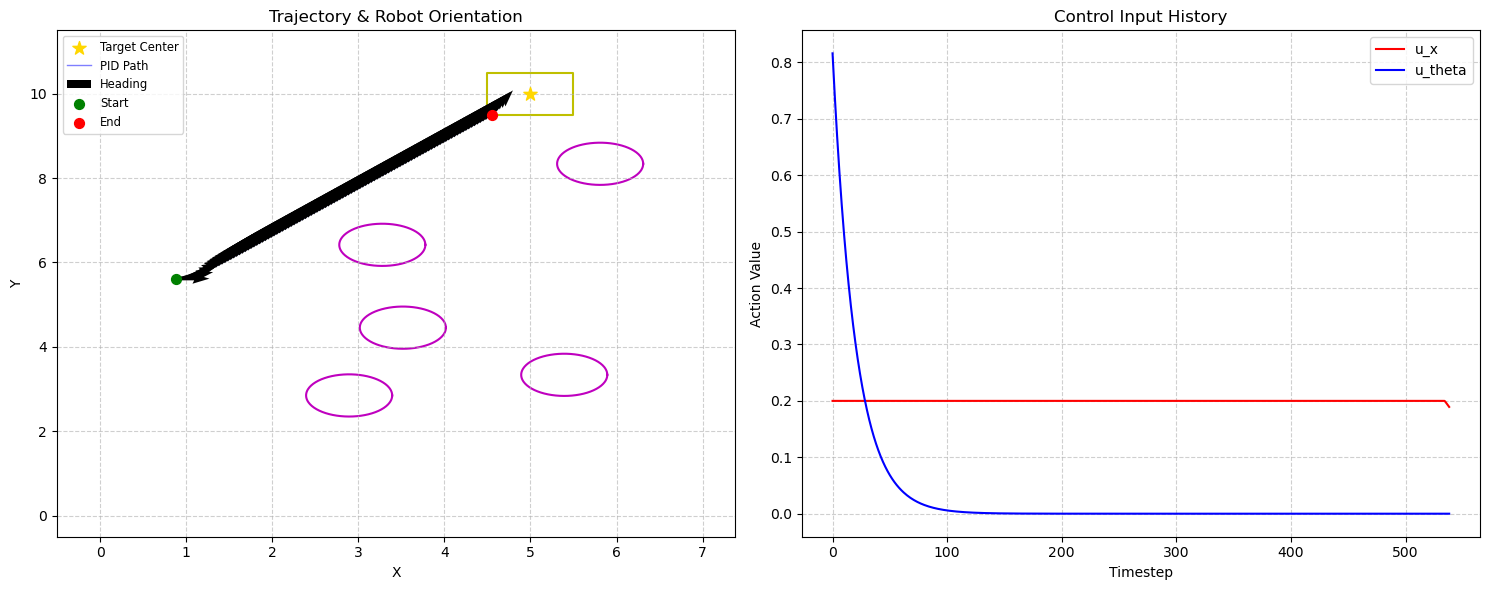


--- Sanity Check Complete ---


In [26]:
# ==============================================================================
# TEST SCRIPT: Environment Sanity Check with PID Controller & Orientation
# ==============================================================================
print("\n--- Starting Environment Sanity Check ---")

from gym_reachability import gym_reachability    # noqa: F401 — registers envs
import matplotlib.pyplot as plt
import numpy as np
import torch
import gymnasium as gym

# 1. Setup a minimal config
class TestConfig:
    timeStep = 0.05
    
test_config = TestConfig()
test_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # 2. Create the environment
    test_env = gym.make(
        "cont-obs-avoid-v0", 
        config=test_config, 
        device=test_device,
        mode='AARA'
    )
    print("Successfully created environment: cont-obs-avoid-v0")

    # 3. Reset
    state, info = test_env.reset()
    state[2] = 0
    print(f"Initial State: {state}")
    
    # Target position from environment (center of target set)
    target_pos = np.array([5.0, 10.0, np.pi/2])

    
    
    # PID (PD) Gains
    P = 0.2
    D = 3
    Kp = np.array([[P, P, 0], [0, 0, 5*P]])
    Kd = np.array([[D, D, 0], [0, 0, 3*D]])
    
    # Storage for plotting
    traj_x, traj_y = [], []
    theta_history = []
    u_history = []
    u_raw = np.zeros(2)  # Initialize raw control for derivative term

    # 4. Step through with PD Controller
    steps = 1000 
    for i in range(steps):
        # current state: [x, y, vx, vy, theta]
        curr_pos = state
        curr_vel = np.array([u_raw[0] * np.cos(curr_pos[2]), u_raw[0] * np.sin(curr_pos[2]), u_raw[1]])  # Approximate velocity from previous control
        #curr_theta = state[2]
        
        # Error calculation
        error = np.array(target_pos - curr_pos)
        theta_des = np.atan2((target_pos[1]-curr_pos[1]), (target_pos[0]-curr_pos[0]))
        error[2] = theta_des - curr_pos[2]

        # PD Control Law: u = Kp * error - Kd * velocity
        u = Kp @ error.T - Kd @ curr_vel.T
        u[0] = np.clip(u[0], -0.2, 0.2)
        # u_raw[1] = np.clip(u_raw[1], 2.0, 2.0)
        # Map to action space [-1, 1] and set theta control to 0
        # u = 2 * (u_raw - np.array([-0.2, -2.0])) / (np.array([0.2, 2.0]) - np.array([-0.2, -2.0])) - 1  # Scale down for action space
        
        print(u)
        # Store for visualization
        traj_x.append(curr_pos[0])
        traj_y.append(curr_pos[1])
        theta_history.append(curr_pos[2])
        u_history.append(u)
        
        # Assume no disturbance for base sanity check
        d = np.zeros(2)
        
        next_state, reward, done, truncated, info = test_env.step((u, d))
        
        if done:
            print(f"Step {i+1}: Episode terminated (Reward: {reward})")
            break
            
        state = next_state

    print(f"Completed {len(traj_x)} steps.")

    # 5. Visualization
    fig = plt.figure(figsize=(15, 6))
    
    # --- Subplot 1: 2D Trajectory with Orientation Arrows ---
    ax1 = fig.add_subplot(1, 2, 1)
    test_env.unwrapped.plot_target_failure_set(ax1)
    
    # Mark the target center
    ax1.scatter(target_pos[0], target_pos[1], color='gold', marker='*', s=100, label='Target Center', zorder=7)
    
    # Plot the trajectory line
    ax1.plot(traj_x, traj_y, color='blue', linewidth=1, alpha=0.5, label='PID Path', zorder=5)
    
    # Plot orientation arrows every N steps to avoid clutter
    arrow_freq = 5
    U = np.cos(np.array(theta_history[::arrow_freq]))
    V = np.sin(np.array(theta_history[::arrow_freq]))
    ax1.quiver(np.array(traj_x[::arrow_freq]), np.array(traj_y[::arrow_freq]), 
               U, V, color='black', scale=20, width=0.005, label='Heading', zorder=6)
    
    ax1.scatter(traj_x[0], traj_y[0], color='green', s=50, label='Start', zorder=6)
    ax1.scatter(traj_x[-1], traj_y[-1], color='red', s=50, label='End', zorder=6)
    
    ax1.set_title("Trajectory & Robot Orientation")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_xlim(test_env.unwrapped.bounds[0, 0] - 0.5, test_env.unwrapped.bounds[0, 1] + 0.5)
    ax1.set_ylim(test_env.unwrapped.bounds[1, 0] - 0.5, test_env.unwrapped.bounds[1, 1] + 0.5)
    ax1.legend(loc='upper left', fontsize='small')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # --- Subplot 2: Control History ---
    ax2 = fig.add_subplot(1, 2, 2)
    u_hist = np.array(u_history)
    ax2.plot(u_hist[:, 0], label='u_x', color='r')
    # ax2.plot(u_hist[:, 1], label='u_y', color='g')
    ax2.plot(u_hist[:, 1], label='u_theta', color='b')
    ax2.set_title("Control Input History")
    ax2.set_xlabel("Timestep")
    ax2.set_ylabel("Action Value")
    # ax2.set_ylim(-1.1, 1.1)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    print("\n--- Sanity Check Complete ---")

except Exception as e:
    print(f"Environment test failed with error: {e}")
    import traceback
    traceback.print_exc()


Namespace(config='config.yaml', num_jobs=16)
experiments/ensemble/3critics/cont-obs-avoid/SAC/AARA/TF-2026-05-06-12_56_55
namespace(envName='cont-obs-avoid-v0', doneType='TF', costType='max_ell_g', randomSeed=0, reward=-1.0, penalty=1.0, scaling=4.0, timeStep=0.05, maxSteps=300, warmup=True, warmupIter=2000, maxUpdates=2000000, updateTimes=10, updatePeriodEps=500000.0, updatePeriodGamma=250000.0, updatePeriodLr=500000.0, memoryCapacity=50000, checkPeriod=50000, batchSize=512, maxModel=100, tau=0.01, hardUpdate=1, softUpdate=True, render=False, double=True, plotTrainValue=True, alpha=0.185, policy='Gaussian', targetUpdateInterval=1, autoAlphaTuning=True, annealing=True, architecture=[512, 512, 512], learningRate=0.001, learningRateActor=0.001, learningRateDecay=0.8, gamma=0.9999, gammaDecay=0.1, eps=0.5, epsEnd=0.05, epsDecay=0.7, actType='Tanh', numCritics=3, mode='AARA', terminalType='max', showTime=True, name='', outFolder='experiments', plotFigure=False, storeFigure=True, storeBest=

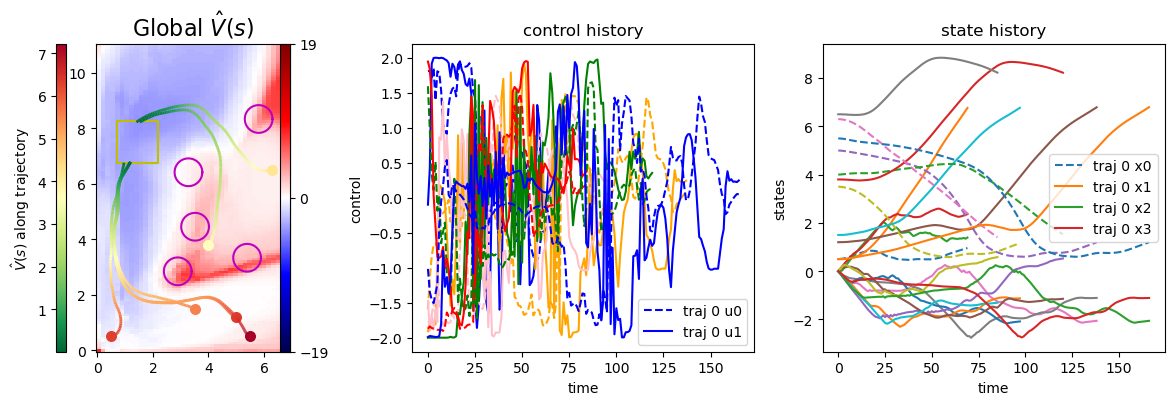

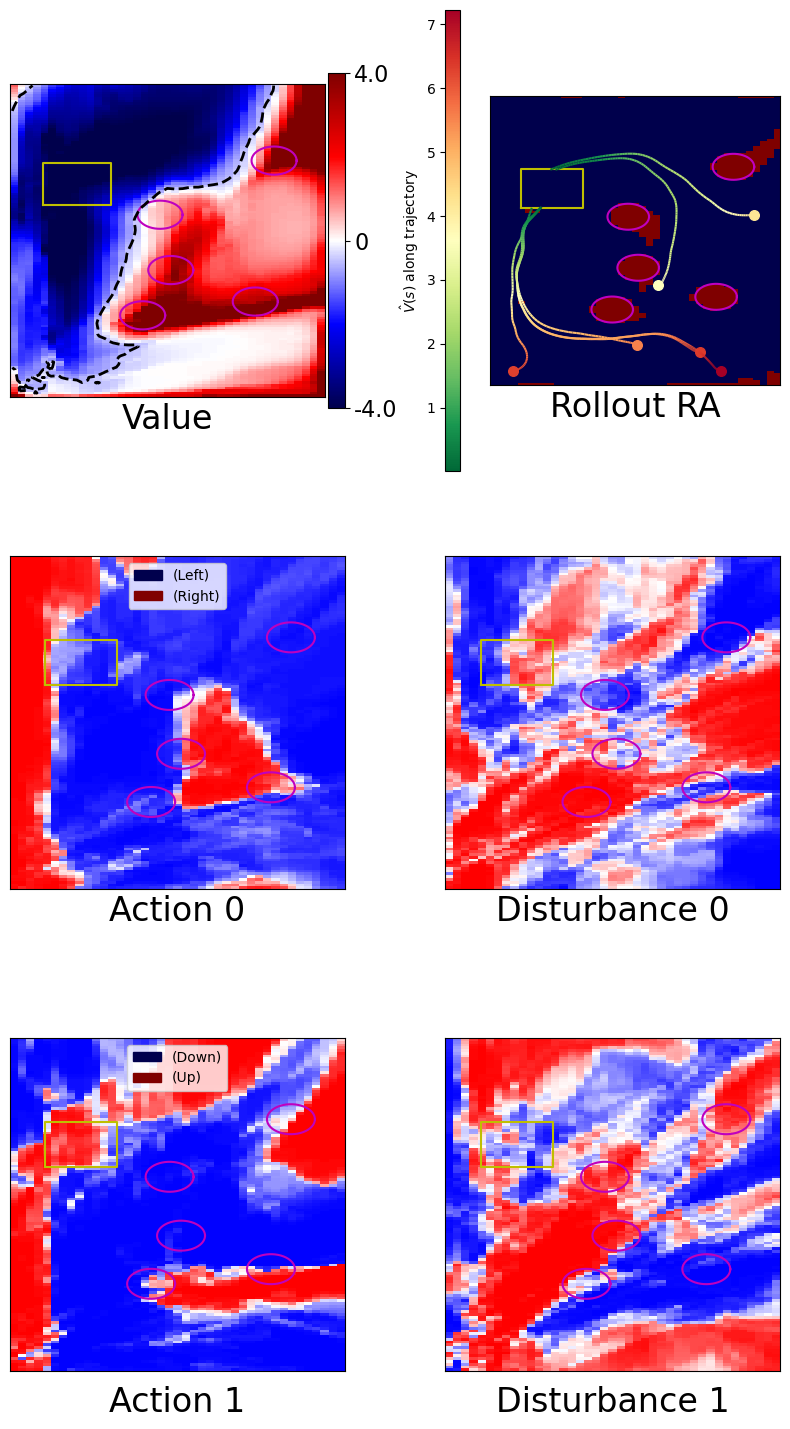

In [2]:
!CUDA_VISIBLE_DEVICES=1
%matplotlib inline
import os
import time
from warnings import simplefilter

import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml
from types import SimpleNamespace

# CHANGED: DDQNEnsemble as protagonist
from RARL.SACTrainer import SACTrainer
from RARL.SAC import SAC
from RARL.config import ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import (
    plot_protagonist_adversary_actions,
    plot_RA_eval,
    PlotConfig,
)
from gym_reachability import gym_reachability    # noqa: F401 — registers envs

import argparse

# matplotlib.use('Agg')
simplefilter(action='ignore', category=FutureWarning)

# == ARGS — YAML config, same as sim_new_point_mass.py ==
parser = argparse.ArgumentParser()
parser.add_argument("--config", default="config.yaml", type=str)
parser.add_argument(
    "--num_jobs", type=int, default=16,
    help="Total number of sim_ensemble.py processes running in parallel. "
         "Used to divide CPU threads evenly across jobs."
)
script_args, unknown = parser.parse_known_args()
print(script_args)
    
outFolder = 'experiments/ensemble/3critics/cont-obs-avoid/SAC/AARA/TF-2026-05-06-12_56_55'
checkpoint_num = 2000000
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')

with open(os.path.join(outFolder, "init_configs.yaml"), "r") as f:
    config_dict = yaml.safe_load(f)

args = SimpleNamespace(**{k: v for section in config_dict.values() for k, v in section.items()})
print(args)

# == CONFIGURATION ==
env_name     = args.envName
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if env_name =="zermelo_show-v0":
    env_title = "point-mass" 
elif env_name == "one_player_reach_avoid_lunar_lander":
    env_title = "lunar-lander"
elif env_name == "cont-obs-avoid-v0":
    env_title = "cont-obs-avoid"

updatePeriod = int(args.maxUpdates / args.updateTimes)
                           
storeFigure  = args.storeFigure
plotFigure   = args.plotFigure



# == Epsilon / gamma schedule — identical to sim_new_point_mass.py ==
if args.mode == 'RA':
    agentMode = 'RA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(args.updatePeriodEps / 10)
        EPS_RESET_PERIOD = args.updatePeriodEps
    else:
        GAMMA_END        = 0.999
        EPS_PERIOD       = args.updatePeriodEps
        EPS_RESET_PERIOD = args.maxUpdates

elif args.mode == 'AARA':
    agentMode = 'AARA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(args.updatePeriodEps / 10)
        EPS_RESET_PERIOD = args.updatePeriodEps
    else:
        GAMMA_END        = 0.999
        EPS_PERIOD       = args.updatePeriodEps
        EPS_RESET_PERIOD = args.maxUpdates

sample_inside_obs = False

# == Environment — passes config=args like updated sim_new_point_mass.py ==
print("\n== Environment Information ==")
env = gym.make(
    env_name, config=args, device=device,
    sample_inside_obs=sample_inside_obs
)

stateDim    = env.unwrapped.state.shape[0]
actionNum   = env.unwrapped.action_space.shape[0]
action_list = np.arange(actionNum)
print("State Dimension: {:d}, ActionSpace Dimension: {:d}".format(stateDim, actionNum))
print(f"Control Range: low = {env.unwrapped.action_space.low}, high = {env.unwrapped.action_space.high}")
print(f"Disturbance Range: low = {env.unwrapped.disturbance_space.low}, high = {env.unwrapped.disturbance_space.high}")

env.reset(seed=args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")

CONFIG = ceConfig(
    DEVICE=device, 
    ENV_NAME=env_name, 
    SEED=args.randomSeed,
    MAX_UPDATES=args.maxUpdates, 
    MAX_EP_STEPS=args.maxSteps,
    BATCH_SIZE=args.batchSize,
    MEMORY_CAPACITY=args.memoryCapacity, 
    ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, 
    # =================== LEARNING RATE .
    GAMMA=args.gamma, 
    GAMMA_PERIOD=args.updatePeriodGamma,
    GAMMA_END=GAMMA_END, 
    GAMMA_DECAY=args.gammaDecay,
    # =================== EXPLORATION PARAMS.
    EPSILON=args.eps,
    EPS_END=args.epsEnd,
    EPS_PERIOD=EPS_PERIOD, 
    EPS_DECAY=args.epsDecay,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, 
    # =================== LEARNING RATE PARAMS.
    LR_C=args.learningRate,
    LR_C_END=args.learningRate * 0.5,
    LR_C_PERIOD=args.updatePeriodLr, 
    LR_C_DECAY=args.learningRateDecay, 
    # =================== LEARNING RATE PARAMS.
    LR_A=args.learningRateActor,
    LR_A_END=args.learningRateActor * 0.5,
    LR_A_PERIOD=args.updatePeriodLr, 
    LR_A_DECAY=args.learningRateDecay, 
    # ===================
    MAX_MODEL=args.maxModel,
    NUM_CRITICS=args.numCritics,
    SELECT_WORST_Q=args.selectWorstQ,
    FIND_MAX_Q=args.findMaxQ,
    SIM_MAX_Q=args.simMaxQ, 
    TIME_STEP=args.timeStep,
    TAU=args.tau,
    HARD_UPDATE=args.hardUpdate,
    SOFT_UPDATE=args.softUpdate,
    RENDER=args.render,
    DOUBLE=args.double,
    REWARD=args.reward,
    PENALTY=args.penalty,
    ALPHA=args.alpha,
    POLICY=args.policy,
    TARGET_UPDATE_INTERVAL=args.targetUpdateInterval,
    AUTO_ALPHA_TUNING=args.autoAlphaTuning
)

# == PROTAGONIST — DDQNEnsemble ==========================================
# CHANGED: DDQNSingle → DDQNEnsemble; dimList and call signature identical
dimList     = [stateDim] + CONFIG.ARCHITECTURE + [actionNum]
sacAgent = SAC(CONFIG, dimList=dimList, action_space=env.unwrapped.action_space, disturbance_space=env.unwrapped.disturbance_space)  
print(sacAgent)
print("We want to use: {}, and Agent uses: {}".format(device, sacAgent.device))
print("Critic is using cuda: ", next(sacAgent.critic.parameters()).is_cuda)

# == TRAINER ==
trainer = SACTrainer(sacAgent, CONFIG)

# == TRAINING — Trainer.learn unchanged ==================================
print("\n== Training Information ==")
vmin        = -1 * args.scaling
vmax        =  1 * args.scaling
checkPeriod = args.checkPeriod

sacAgent.load_checkpoint(checkpoint_num, outFolder, evaluate=True)

nx = 41 
ny = 121
xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)
na = env.unwrapped.action_space.shape[0]
nd = env.unwrapped.disturbance_space.shape[0]

resultMtx      = np.empty((nx, ny), dtype=int)
actDistMtx     = np.empty((nx, ny, na), dtype=float)
disturbDistMtx = np.empty((nx, ny, nd), dtype=float)
# ADDED: uncertainty matrices
varMtx         = np.empty((nx, ny))
disAgreeMtx    = np.empty((nx, ny))

analytic_max_fail = 0
analytic_min_fail = 0

it = np.nditer(resultMtx, flags=['multi_index'])
while not it.finished:
    idx_cell = it.multi_index
    print(idx_cell, end='\r')
    x, y  = xs[idx_cell[0]], ys[idx_cell[1]]
    state = np.array([x, y, 0, 0])

    stateTensor  = torch.FloatTensor(state).to(device).unsqueeze(0)
    _, _, action = sacAgent.protagonist.sample(stateTensor)
    _, _, disturbance = sacAgent.adversary.sample(stateTensor)

    actDistMtx    [idx_cell] = action.cpu().detach().numpy()
    disturbDistMtx[idx_cell] = disturbance.cpu().detach().numpy()

    # ADDED: epistemic uncertainty at this state
    # unc = protagonist.get_uncertainty(stateTensor)
    # varMtx    [idx_cell] = unc["epistemic_uncertainty"].item()
    # disAgreeMtx[idx_cell] = unc["safe_disagreement"].item()

    _, result, _, _ = env.unwrapped.simulate_one_trajectory(
        sacAgent, T=250, state=state
    )

    g_x_val         = env.unwrapped.safety_margin(state)
    # inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    # inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x_val > 0:
        analytic_min_fail += 1
        analytic_max_fail += 1
    # else:
    #     if inside_max_diag: analytic_max_fail += 1
    #     if inside_min_diag: analytic_min_fail += 1

    resultMtx[idx_cell] = result
    it.iternext()

print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(
    1 - analytic_max_fail / (nx * ny)))
print('Analytical Success Rate for No Disturbances-{:.3f}'.format(
    1 - analytic_min_fail / (nx * ny)))
print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format(
    (resultMtx == 1).sum() / (nx * ny)))

cfg = PlotConfig(
        nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax,
        resultMtx=resultMtx, actDistMtx=actDistMtx,
        disturbDistMtx=disturbDistMtx, figureFolder=figureFolder,
        plotFigure=plotFigure, storeFigure=storeFigure, actionNum=actionNum,
    )

# filePath = os.path.join(outFolder, 'train')
# trainDict = load_obj(filePath)
# trainRecords = trainDict['trainRecords']
# trainProgress = trainDict['trainProgress']
# resultMtx = trainDict['resultMtx']
# actDistMtx = trainDict['actDistMtx']
# disturbDistMtx = trainDict['disturbDistMtx']

# cfg = PlotConfig(
#         nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax,
#         resultMtx=resultMtx, actDistMtx=actDistMtx,
#         disturbDistMtx=disturbDistMtx, figureFolder=figureFolder,
#         plotFigure=False, storeFigure=False, actionNum=actionNum,
#     )

# plot_RA_eval(env, sacAgent, cfg)

env.unwrapped.visualize(sacAgent, vmin=vmin, vmax=vmax, nx=nx, ny=ny)

plot_RA_eval(env, sacAgent, cfg)

In [14]:
obs = env.unwrapped.obstacles

obs = torch.cat([
    torch.cat([
        torch.from_numpy(center).flatten(),
        torch.tensor([rad], dtype=torch.float32)
    ])
    for center, rad in obs
]).float().to(device)

torch.cat([torch.FloatTensor(state).to(device), obs]).unsqueeze(0)

print(obs)

state = np.array([x, y, 0, 0])
print(state)

print(np.array(obs.cpu()))

tensor([5.8096, 8.3375, 0.5000, 2.8935, 2.8481, 0.5000, 3.5176, 4.4543, 0.5000,
        5.3925, 3.3364, 0.5000, 3.2790, 6.4172, 0.5000], device='cuda:0')
[ 6.88 11.    0.    0.  ]
[5.8096223 8.337499  0.5       2.8935325 2.8480842 0.5       3.51757
 4.4542756 0.5       5.3925343 3.33644   0.5       3.278987  6.4172025
 0.5      ]


/tmp/ipykernel_676735/2371199732.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(obs.cpu()))


In [ ]:
!CUDA_VISIBLE_DEVICES=1
%matplotlib inline
import os
import time
from warnings import simplefilter

import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import yaml
from types import SimpleNamespace

# CHANGED: DDQNEnsemble as protagonist
from RARL.SACTrainer import SACTrainer
from RARL.SAC import SAC
from RARL.config import ceConfig
from RARL.utils import save_obj, load_obj
from utils.utils import (
    plot_protagonist_adversary_actions,
    plot_RA_eval,
    PlotConfig,
)
from gym_reachability import gym_reachability    # noqa: F401 — registers envs

import argparse

# matplotlib.use('Agg')
simplefilter(action='ignore', category=FutureWarning)

# == ARGS — YAML config, same as sim_new_point_mass.py ==
parser = argparse.ArgumentParser()
parser.add_argument("--config", default="config.yaml", type=str)
parser.add_argument(
    "--num_jobs", type=int, default=16,
    help="Total number of sim_ensemble.py processes running in parallel. "
         "Used to divide CPU threads evenly across jobs."
)
script_args, unknown = parser.parse_known_args()
print(script_args)
    
outFolder = 'experiments/ensemble/3critics/cont-obs-avoid/SAC/AARA/TF-2026-05-20-11_00_15'
print(outFolder)
figureFolder = os.path.join(outFolder, 'figure')

with open(os.path.join(outFolder, "init_configs.yaml"), "r") as f:
    config_dict = yaml.safe_load(f)

args = SimpleNamespace(**{k: v for section in config_dict.values() for k, v in section.items()})
print(args)

# == CONFIGURATION ==
env_name     = args.envName
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if env_name =="zermelo_show-v0":
    env_title = "point-mass" 
elif env_name == "one_player_reach_avoid_lunar_lander":
    env_title = "lunar-lander"
elif env_name == "cont-obs-avoid-v0":
    env_title = "cont-obs-avoid"

updatePeriod = int(args.maxUpdates / args.updateTimes)
                           
storeFigure  = args.storeFigure
plotFigure   = args.plotFigure



# == Epsilon / gamma schedule — identical to sim_new_point_mass.py ==
if args.mode == 'RA':
    agentMode = 'RA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(args.updatePeriodEps / 10)
        EPS_RESET_PERIOD = args.updatePeriodEps
    else:
        GAMMA_END        = 0.999
        EPS_PERIOD       = args.updatePeriodEps
        EPS_RESET_PERIOD = args.maxUpdates

elif args.mode == 'AARA':
    agentMode = 'AARA'
    if args.annealing:
        GAMMA_END        = 0.999999
        EPS_PERIOD       = int(args.updatePeriodEps / 10)
        EPS_RESET_PERIOD = args.updatePeriodEps
    else:
        GAMMA_END        = 0.999
        EPS_PERIOD       = args.updatePeriodEps
        EPS_RESET_PERIOD = args.maxUpdates

sample_inside_obs = False

# == Environment — passes config=args like updated sim_new_point_mass.py ==
print("\n== Environment Information ==")
env = gym.make_vec(
    env_name, num_envs=6, config=args, device=device,
    sample_inside_obs=sample_inside_obs
)

s, _ = env.reset()

print(s)

done = np.array([True, False, True, False, False, True])

s_, _ = env.envs[0].reset()

print(s_)

stateDim    = env.unwrapped.state.shape[0]
actionNum   = env.unwrapped.action_space.shape[0]
action_list = np.arange(actionNum)
print("State Dimension: {:d}, ActionSpace Dimension: {:d}".format(stateDim, actionNum))
print(f"Control Range: low = {env.unwrapped.action_space.low}, high = {env.unwrapped.action_space.high}")
print(f"Disturbance Range: low = {env.unwrapped.disturbance_space.low}, high = {env.unwrapped.disturbance_space.high}")

env.reset(seed=args.randomSeed)


# == Agent CONFIG ==
print("\n== Agent Information ==")

CONFIG = ceConfig(
    DEVICE=device, 
    ENV_NAME=env_name, 
    SEED=args.randomSeed,
    MAX_UPDATES=args.maxUpdates, 
    MAX_EP_STEPS=args.maxSteps,
    BATCH_SIZE=args.batchSize,
    MEMORY_CAPACITY=args.memoryCapacity, 
    ARCHITECTURE=args.architecture,
    ACTIVATION=args.actType, 
    # =================== LEARNING RATE .
    GAMMA=args.gamma, 
    GAMMA_PERIOD=args.updatePeriodGamma,
    GAMMA_END=GAMMA_END, 
    GAMMA_DECAY=args.gammaDecay,
    # =================== EXPLORATION PARAMS.
    EPSILON=args.eps,
    EPS_END=args.epsEnd,
    EPS_PERIOD=EPS_PERIOD, 
    EPS_DECAY=args.epsDecay,
    EPS_RESET_PERIOD=EPS_RESET_PERIOD, 
    # =================== LEARNING RATE PARAMS.
    LR_C=args.learningRate,
    LR_C_END=args.learningRate * 0.5,
    LR_C_PERIOD=args.updatePeriodLr, 
    LR_C_DECAY=args.learningRateDecay, 
    # =================== LEARNING RATE PARAMS.
    LR_A=args.learningRateActor,
    LR_A_END=args.learningRateActor * 0.5,
    LR_A_PERIOD=args.updatePeriodLr, 
    LR_A_DECAY=args.learningRateDecay, 
    # ===================
    MAX_MODEL=args.maxModel,
    NUM_CRITICS=args.numCritics,
    SELECT_WORST_Q=args.selectWorstQ,
    FIND_MAX_Q=args.findMaxQ,
    SIM_MAX_Q=args.simMaxQ, 
    TIME_STEP=args.timeStep,
    TAU=args.tau,
    HARD_UPDATE=args.hardUpdate,
    SOFT_UPDATE=args.softUpdate,
    RENDER=args.render,
    DOUBLE=args.double,
    REWARD=args.reward,
    PENALTY=args.penalty,
    ALPHA=args.alpha,
    POLICY=args.policy,
    TARGET_UPDATE_INTERVAL=args.targetUpdateInterval,
    AUTO_ALPHA_TUNING=args.autoAlphaTuning
)

# == PROTAGONIST — DDQNEnsemble ==========================================
# CHANGED: DDQNSingle → DDQNEnsemble; dimList and call signature identical
dimList     = [stateDim] + CONFIG.ARCHITECTURE + [actionNum]
sacAgent = SAC(CONFIG, dimList=dimList, action_space=env.unwrapped.action_space, disturbance_space=env.unwrapped.disturbance_space)  
print(sacAgent)
print("We want to use: {}, and Agent uses: {}".format(device, sacAgent.device))
print("Critic is using cuda: ", next(sacAgent.critic.parameters()).is_cuda)

# == TRAINER ==
trainer = SACTrainer(sacAgent, CONFIG)

# == TRAINING — Trainer.learn unchanged ==================================
print("\n== Training Information ==")
vmin        = -1 * args.scaling
vmax        =  1 * args.scaling
checkPeriod = args.checkPeriod

sacAgent.load_checkpoint(2000000, outFolder, evaluate=True)

nx = 41 
ny = 121
xs = np.linspace(env.unwrapped.bounds[0, 0], env.unwrapped.bounds[0, 1], nx)
ys = np.linspace(env.unwrapped.bounds[1, 0], env.unwrapped.bounds[1, 1], ny)
na = env.unwrapped.action_space.shape[0]
nd = env.unwrapped.disturbance_space.shape[0]

resultMtx      = np.empty((nx, ny), dtype=int)
actDistMtx     = np.empty((nx, ny, na), dtype=float)
disturbDistMtx = np.empty((nx, ny, nd), dtype=float)
# ADDED: uncertainty matrices
varMtx         = np.empty((nx, ny))
disAgreeMtx    = np.empty((nx, ny))

analytic_max_fail = 0
analytic_min_fail = 0

state = np.array([2, 2])
stateTensor  = torch.FloatTensor(state).to(device).unsqueeze(0)
_, _, action = sacAgent.protagonist.sample(stateTensor)
_, _, disturbance = sacAgent.adversary.sample(stateTensor)
q1,  q2 = sacAgent.critic(stateTensor, action, disturbance)
print(f"Value Estimate at (2, 2): {min(q1,q2).item():.3f}")
    
trajectory, result, _, _ = env.unwrapped.simulate_one_trajectory(
    sacAgent, T=250, state=state
)
print(f"Trajectory result at (2, 2): {result}")



it = np.nditer(resultMtx, flags=['multi_index'])
while not it.finished:
    idx_cell = it.multi_index
    print(idx_cell, end='\r')
    x, y  = xs[idx_cell[0]], ys[idx_cell[1]]
    state = np.array([x, y])

    stateTensor  = torch.FloatTensor(state).to(device).unsqueeze(0)
    _, _, action = sacAgent.protagonist.sample(stateTensor)
    _, _, disturbance = sacAgent.adversary.sample(stateTensor)

    actDistMtx    [idx_cell] = action.cpu().detach().numpy()
    disturbDistMtx[idx_cell] = disturbance.cpu().detach().numpy()

    # ADDED: epistemic uncertainty at this state
    # unc = protagonist.get_uncertainty(stateTensor)
    # varMtx    [idx_cell] = unc["epistemic_uncertainty"].item()
    # disAgreeMtx[idx_cell] = unc["safe_disagreement"].item()

    _, result, _, _ = env.unwrapped.simulate_one_trajectory(
        sacAgent, T=250, state=state
    )

    g_x_val         = env.unwrapped.safety_margin(state)
    # inside_max_diag = env.unwrapped.is_inside_diagonal_region(state)
    # inside_min_diag = env.unwrapped.is_inside_diagonal_region(state, min=True)
    if g_x_val > 0:
        analytic_min_fail += 1
        analytic_max_fail += 1
    # else:
    #     if inside_max_diag: analytic_max_fail += 1
    #     if inside_min_diag: analytic_min_fail += 1

    resultMtx[idx_cell] = result
    it.iternext()

print('Analytical Success Rate for Maximal Disturbances-{:.3f}'.format(
    1 - analytic_max_fail / (nx * ny)))
print('Analytical Success Rate for No Disturbances-{:.3f}'.format(
    1 - analytic_min_fail / (nx * ny)))
print('Best RA Success Rate with Adversarial Disturbances-{:.3f}'.format(
    (resultMtx == 1).sum() / (nx * ny)))

cfg = PlotConfig(
        nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax,
        resultMtx=resultMtx, actDistMtx=actDistMtx,
        disturbDistMtx=disturbDistMtx, figureFolder=figureFolder,
        plotFigure=plotFigure, storeFigure=storeFigure, actionNum=actionNum,
    )

# filePath = os.path.join(outFolder, 'train')
# trainDict = load_obj(filePath)
# trainRecords = trainDict['trainRecords']
# trainProgress = trainDict['trainProgress']
# resultMtx = trainDict['resultMtx']
# actDistMtx = trainDict['actDistMtx']
# disturbDistMtx = trainDict['disturbDistMtx']

# cfg = PlotConfig(
#         nx=nx, ny=ny, xs=xs, ys=ys, vmin=vmin, vmax=vmax,
#         resultMtx=resultMtx, actDistMtx=actDistMtx,
#         disturbDistMtx=disturbDistMtx, figureFolder=figureFolder,
#         plotFigure=False, storeFigure=False, actionNum=actionNum,
#     )

# plot_RA_eval(env, sacAgent, cfg)

env.unwrapped.visualize(sacAgent, vmin=vmin, vmax=vmax, nx=nx, ny=ny)

plot_RA_eval(env, sacAgent, cfg)

Namespace(config='config.yaml', num_jobs=16)
experiments/ensemble/3critics/cont-obs-avoid/SAC/AARA/TF-2026-05-20-11_00_15
namespace(envName='cont-obs-avoid-v0', numEnvs=5, doneType='TF', costType='max_ell_g', addObs=False, randomSeed=0, reward=-1.0, penalty=1.0, scaling=4.0, timeStep=0.05, maxSteps=300, warmup=True, warmupIter=2000, maxUpdates=2000000, updateTimes=10, updatePeriodEps=500000.0, updatePeriodGamma=250000.0, updatePeriodLr=500000.0, memoryCapacity=50000, checkPeriod=50000, batchSize=2048, maxModel=100, tau=0.01, hardUpdate=1, softUpdate=True, render=False, double=True, plotTrainValue=True, alpha=0.185, policy='Gaussian', targetUpdateInterval=1, autoAlphaTuning=True, annealing=True, architecture=[512, 512], learningRate=0.001, learningRateActor=0.001, learningRateDecay=0.8, gamma=0.9999, gammaDecay=0.1, eps=0.5, epsEnd=0.05, epsDecay=0.7, actType='Tanh', numCritics=3, mode='AARA', terminalType='max', showTime=True, name='', outFolder='experiments', plotFigure=False, storeFi

AttributeError: 'SyncVectorEnv' object has no attribute 'state'